# Imports

## Imports and Data Loading

In this step, the required libraries are imported and the project path is configured so that the notebook can correctly access modules from the `src` folder.

The preprocessed test dataset (`X_test` and `y_test`) is then loaded from the `processed` data directory.
After that, all previously trained models are loaded from saved `.pkl` files using `joblib`.

This allows the notebook to evaluate and compare all models on the same test set without retraining them.

In [3]:
import sys
import os

# Fix path so Python can find 'src'
sys.path.append(os.path.abspath('../../'))

# Now imports will work
from src.utils.paths import PROCESSED_DATA_DIR

import pandas as pd
import joblib

# Load test data
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").values.ravel()

# Load models
dt = joblib.load("../../models/decision_tree.pkl")
knn = joblib.load("../../models/knn.pkl")
lr = joblib.load("../../models/logistic.pkl")
rf = joblib.load("../../models/random_forest.pkl")
xgb = joblib.load("../../models/xgboost.pkl")
cat = joblib.load("../../models/catboost.pkl")

# Model Evaluation and Comparison

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

def evaluate(model, name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred  # fallback

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })

# Run evaluation
evaluate(dt, "Decision Tree")
evaluate(knn, "KNN")
evaluate(lr, "Logistic Regression")
evaluate(rf, "Random Forest")
evaluate(xgb, "XGBoost")
evaluate(cat, "CatBoost")

# Create comparison table
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC
5,CatBoost,0.967434,0.944993,0.928621,0.936735,0.963291
2,Logistic Regression,0.967254,0.942456,0.930700,0.936541,0.956234
3,Random Forest,0.967254,0.945583,0.927235,0.936319,0.965998
4,XGBoost,0.965815,0.942131,0.925156,0.933566,0.959441
0,Decision Tree,0.965095,0.940720,0.923770,0.932168,0.956956
1,KNN,0.958978,0.922756,0.918919,0.920833,0.953530


## Model Evaluation and Comparison

In this step, a unified evaluation pipeline is defined to ensure that all models are assessed consistently.

For each model, predictions are generated on the test dataset. If the model supports probability estimation (`predict_proba`), these probabilities are used to compute the ROC AUC score. Otherwise, predicted labels are used as a fallback.

The following evaluation metrics are computed for each model:
- **Accuracy** – overall prediction correctness
- **Precision** – proportion of correctly predicted positive instances
- **Recall** – ability to correctly identify actual positive instances
- **F1 Score** – harmonic mean of precision and recall
- **ROC AUC** – model’s ability to distinguish between classes

All results are stored in a structured format and combined into a single DataFrame, which is then sorted by F1 score to highlight the best-performing models.

# Visual Comparison


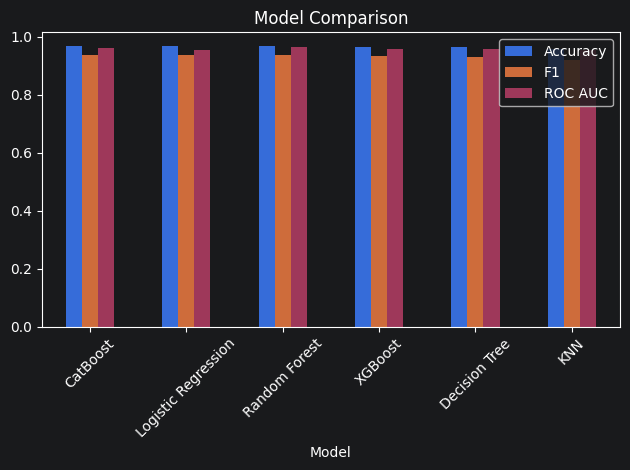

In [10]:
# General plot
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "F1", "ROC AUC"]].plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

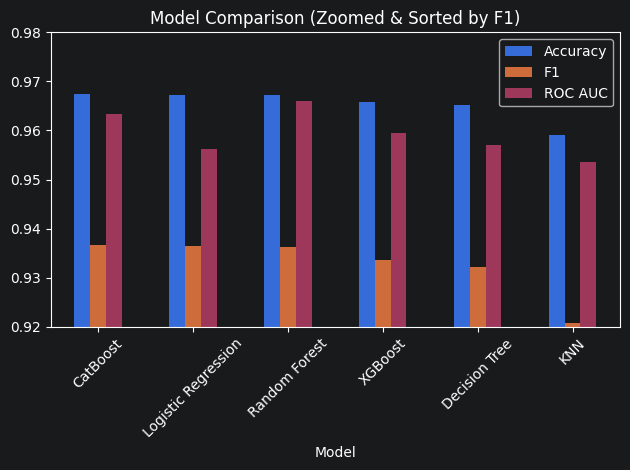

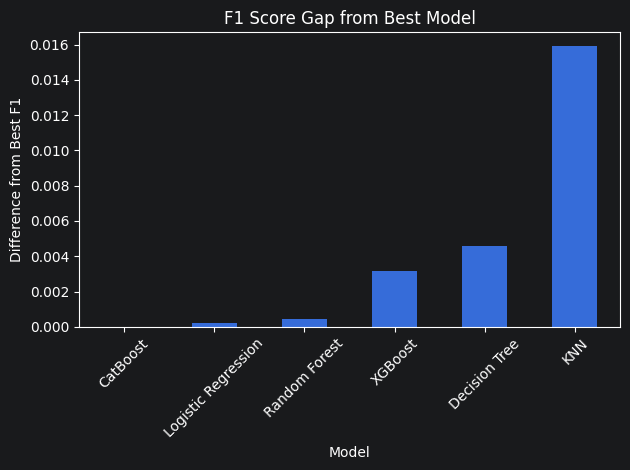

In [9]:
import matplotlib.pyplot as plt

# Sort by F1 for cleaner ranking
sorted_df = results_df.sort_values(by="F1", ascending=False)

# --- 1. Zoomed comparison plot ---
ax = sorted_df.set_index("Model")[["Accuracy", "F1", "ROC AUC"]].plot(kind="bar")
plt.ylim(0.92, 0.98)  # zoom into meaningful differences
plt.xticks(rotation=45)
plt.title("Model Comparison (Zoomed & Sorted by F1)")
plt.tight_layout()
plt.show()

# --- 2. Gap from best model (more insightful) ---
best_f1 = results_df["F1"].max()
results_df["F1_gap"] = best_f1 - results_df["F1"]

gap_df = results_df.sort_values(by="F1_gap")

gap_df.set_index("Model")["F1_gap"].plot(kind="bar")
plt.title("F1 Score Gap from Best Model")
plt.ylabel("Difference from Best F1")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visual Comparison of Model Performance

To better interpret the results, two types of visualizations are used:

- A **standard bar chart** to display the absolute values of Accuracy, F1 Score, and ROC AUC for each model
- A **zoomed and sorted bar chart**, along with an **F1 gap plot**, to highlight subtle differences between models

The standard chart confirms that all models achieve high performance, with values clustered around 0.96–0.97. However, due to the small variation between models, these differences are difficult to distinguish at full scale.

The zoomed chart focuses on a narrower range, making small performance differences visible. Additionally, the F1 gap plot shows how far each model is from the best-performing model, providing a clearer perspective on relative performance.

Together, these visualizations help identify not only which models perform best, but also whether the differences between them are meaningful.

## Interpretation and Model Ranking

The comparison results show that all models perform at a high level, with only minor differences between them.

### Overall Ranking

Based on the F1 Score (primary metric), the models can be ranked as follows:

1. CatBoost
2. Logistic Regression
3. Random Forest
4. XGBoost
5. Decision Tree
6. KNN

### Key Observations from the Visualizations

- **Minimal differences among top models**
  The zoomed bar chart shows that CatBoost, Logistic Regression, and Random Forest are extremely close in performance.
  The F1 gap plot confirms this, with differences from the best model being nearly zero for these models.

- **Small but visible performance drop in mid-tier models**
  XGBoost and Decision Tree show slightly larger gaps in F1 score. While still strong, they are consistently below the top group across all metrics.

- **Clear separation of KNN**
  KNN shows the largest gap from the best model in the F1 gap plot, confirming it as the weakest performer in this comparison.

### Important Insight

The F1 gap visualization highlights that:
- The top 3 models are practically indistinguishable in performance
- The differences between them are extremely small and unlikely to be statistically significant
- The performance gap only becomes noticeable when comparing against weaker models like KNN

This suggests that the problem is well-defined and can be effectively solved by multiple algorithms, leading to performance convergence among strong models.

### Implications for Model Selection

Since the top-performing models show nearly identical results, the final choice should be based on:

- **Interpretability** (favoring Logistic Regression)
- **Stability and robustness** (favoring Random Forest)
- **Maximum performance regardless of complexity** (favoring CatBoost)

Therefore, the decision is not about finding a single “best” model, but about selecting the most appropriate one given practical constraints and project goals.

## Limitations

- The dataset may not capture all factors influencing personality traits
- Some models (e.g., KNN) are sensitive to feature scaling
- Boosting models were not fully tuned, which may affect fairness of comparison
- Performance differences between top models are very small and may not be statistically significant

## Future Work

- Perform more extensive hyperparameter tuning for boosting models
- Explore additional features or feature engineering techniques
- Test models on external datasets for better generalization assessment
- Apply explainability methods such as SHAP for deeper insights

## Final Model Selection

After comparing all baseline models, Logistic Regression is selected as the final model.

Although CatBoost achieved the highest F1 score, the difference is negligible. Logistic Regression offers comparable performance while being significantly simpler, faster, and more interpretable.

This makes it the most balanced choice for this problem. However we have to keep in mind the possibility of performance changes after hyperparameter tuning.